In [1]:
# E.R.M.E.S. - Fase 1: Exploratory Data Analysis (EDA)
In questo notebook analizziamo il dataset FER-2013 per identificare:
1. Sbilanciamento delle classi (Imbalanced Data).
2. Dati mancanti o corrotti (Missing Values/Outliers).
3. Strategie di pre-processing necessarie.

SyntaxError: invalid syntax (2875829952.py, line 2)

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

base_dir = Path('../data/fer2013/train')
print(f"Percorso dataset: {base_dir.resolve()}")

Percorso dataset: C:\Users\Ugo\Dropbox\PC\Desktop\UGO\Scuola\Unisa\Corsi di Studio\ANNO 3 SEMESTRE 1\Machine Learning\PROGETTO\ERMES\data\fer2013\train



---Conteggio immagini per categoria---
angry: 3995
disgust: 436
fear: 4097
happy: 7215
neutral: 4965
sad: 4830
surprise: 3171


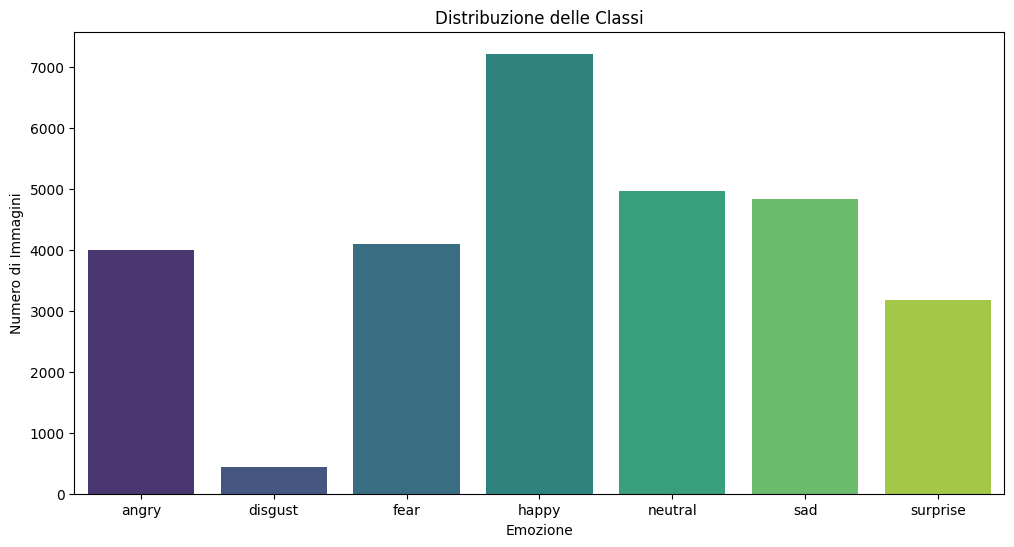

In [2]:
emotion_counts = {}

print("\n---Conteggio immagini per categoria---")
for emotion_dir in base_dir.iterdir():
    if emotion_dir.is_dir():
        # Conta i file all'interno della cartella
        count = sum(1 for _ in emotion_dir.iterdir())
        emotion_counts[emotion_dir.name] = count
        print(f"{emotion_dir.name}: {count}")

# Creazione Grafico
plt.figure(figsize=(12, 6))
sns.barplot(
    x=list(emotion_counts.keys()), 
    y=list(emotion_counts.values()), 
    hue=list(emotion_counts.keys()), 
    palette="viridis", 
    legend=False
)
plt.title("Distribuzione delle Classi")
plt.xlabel("Emozione")
plt.ylabel("Numero di Immagini")
plt.show()

In [3]:
from typing import Tuple, Set

def check_images(directory: Path) -> Tuple[int, int, Set[Tuple[int, ...]]]:
    """
    Scansiona una directory di immagini per verificare l'integrità dei file 
    e raccogliere informazioni sulle dimensioni (shape).
    
    Args:
        directory (Path): Percorso principale contenente le sottocartelle delle classi.
        
    Returns:
        Tuple[int, int, Set]: Numero totale, numero file corrotti, set delle risoluzioni uniche trovate.
    """
    corrupt_count = 0
    total_count = 0
    unique_shapes = set()
    
    print("Scansione integrità e risoluzione file...")
    
    for emotion_dir in directory.iterdir():
        if not emotion_dir.is_dir(): 
            continue
            
        for img_path in emotion_dir.iterdir():
            total_count += 1
            
            try:
                # Prova a caricare l'immagine
                img = cv2.imread(str(img_path))
                if img is None:
                    print(f"File corrotto trovato: {img_path.name}")
                    corrupt_count += 1
                else:
                    # Registra la shape (Altezza, Larghezza, Canali)
                    unique_shapes.add(img.shape)
            except Exception as e:
                print(f"Errore su {img_path.name}: {e}")
                corrupt_count += 1
                
    return total_count, corrupt_count, unique_shapes

# Esecuzione e stampa risultati
total, corrupt, shapes = check_images(base_dir)

print("\n--- Risultati Scansione ---")
print(f"Immagini totali: {total}")
print(f"Immagini corrotte/illeggibili: {corrupt}")
print(f"Risoluzioni rilevate nel dataset (H, W, Channels): {shapes}")

Scansione integrità e risoluzione file...

--- Risultati Scansione ---
Immagini totali: 28709
Immagini corrotte/illeggibili: 0
Risoluzioni rilevate nel dataset (H, W, Channels): {(48, 48, 3)}


In [ ]:
## Conclusioni dell'analisi
1. **Sbilanciamento:** Il dataset (28709 immagini totali) presenta uno sbilanciamento. La classe maggioritaria "Happy" (7215 esempi) è circa 16 volte più numerosa della classe minoritaria "Disgust" (436 esempi).
   * *Soluzione:* In fase di training sarà tassativo applicare `class_weights` alla Loss function per penalizzare pesantemente gli errori sulla classe "Disgust", abbinati a tecniche di `Data Augmentation`. La metrica principale di valutazione dovrà essere la F1-Score, poiché l'Accuracy globale risulterebbe fuorviante.
2. **Integrità del Dataset:** Ottima. La scansione ha verificato 0 immagini corrotte o illeggibili.
3. **Formato:** Tutte le immagini presentano una risoluzione fissa e omogenea di 48x48 pixel. Tuttavia, la shape rilevata `(48, 48, 3)` indica la presenza di 3 canali colore. Essendo le espressioni nativamente in scala di grigi, i canali contengono dati triplicati e ridondanti.
   * *Soluzione:* In fase di pre-processing (Fase 2) forzeremo la conversione a singolo canale per ottenere tensori `(48, 48, 1)`. Questo ridurrà il carico computazionale (parametri della prima rete convoluzionale) senza alcuna perdita di informazione utile.